# Training the MobileNetV2 + LSTM using Raw Frame Approach

**Dataset:** https://www.kaggle.com/datasets/ayoznur/hatrec-video-dataset


| File | Task | Label |
|------|------|-------|
| task_0 | Assembling the spring | 0 |
| task_1 | Placing white plastic part | 1 |
| task_2 | Screwing-1 | 2 |
| task_3 | Inflating the valve | 3 |
| task_4 | Placing black plastic part | 4 |
| task_5 | Screwing-2 | 5 |
| task_6 | Fixing the cable | 6 |



**Pipeline:**

Video → Sample N frames → Resize 112x112 → MobileNetV2 (feature extractor) → Sequence of features → LSTM → Softmax (7 classes)


## **1. Import Library**

In [ ]:
!pip install -q --upgrade numpy
!pip install -q tensorflow==2.19.0
!pip install -q scikit-learn matplotlib seaborn tqdm joblib
!pip uninstall numpy -y
!pip install numpy==1.26.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 36.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 832.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 83.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but y

In [ ]:
import os, json, warnings, gc
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0e1117', 'axes.facecolor': '#1e1e2e',
    'text.color': 'white', 'axes.labelcolor': 'white',
    'xtick.color': 'white', 'ytick.color': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.2
})

## **2. Load dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = Path('/content/drive/MyDrive/Colab Notebooks/00. Final Project/01. Dataset FN/Cycles')
OUTPUT_PATH  = Path('/content/hatrec_output')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

LABEL_MAP = {
    'task_0': {'id': 0, 'name': 'Assembling the spring'},
    'task_1': {'id': 1, 'name': 'Placing white plastic part'},
    'task_2': {'id': 2, 'name': 'Screwing-1'},
    'task_3': {'id': 3, 'name': 'Inflating the valve'},
    'task_4': {'id': 4, 'name': 'Placing black plastic part'},
    'task_5': {'id': 5, 'name': 'Screwing-2'},
    'task_6': {'id': 6, 'name': 'Fixing the cable'},
}
N_CLASSES   = len(LABEL_MAP)
CLASS_NAMES = [LABEL_MAP[f'task_{i}']['name'] for i in range(N_CLASSES)]
SHORT_NAMES = ['Spring', 'White part', 'Screw-1', 'Inflate', 'Black part', 'Screw-2', 'Cable']

# Set up the input
IMG_SIZE    = (112, 112)
N_FRAMES    = 4
BATCH_SIZE  = 8
EPOCHS      = 15

# Data splittin
TRAIN_CYCLES = list(range(0, 54))    # 54 cycles (69%)
VAL_CYCLES   = list(range(54, 66))   # 12 cycles (15%)
TEST_CYCLES  = list(range(66, 78))   # 12 cycles (15%)


print(f'   Dataset path : {DATASET_PATH}')
print(f'   Classes      : {N_CLASSES}')
print(f'   Frame/video  : {N_FRAMES}')
print(f'   Image size   : {IMG_SIZE}')
print(f'   Train cycles : {len(TRAIN_CYCLES)} | Val: {len(VAL_CYCLES)} | Test: {len(TEST_CYCLES)}')

   Dataset path : /content/drive/MyDrive/Colab Notebooks/00. Final Project/01. Dataset FN/Cycles
   Classes      : 7
   Frame/video  : 4
   Image size   : (112, 112)
   Train cycles : 54 | Val: 12 | Test: 12


## **3. Data Splitting**

In [ ]:
video_records = []

all_cycles = sorted(DATASET_PATH.iterdir(), key=lambda p: int(p.name.split('_')[1]))

for cycle_dir in all_cycles:
    if not cycle_dir.is_dir():
        continue
    cycle_num = int(cycle_dir.name.split('_')[1])

    if cycle_num < 54:
        split = 'train'
    elif cycle_num < 66:
        split = 'val'
    else:
        split = 'test'

    for task_key, task_info in LABEL_MAP.items():
        video_path = cycle_dir / f'{cycle_dir.name}_{task_key}.mp4'
        if video_path.exists():
            video_records.append({
                'cycle'     : cycle_dir.name,
                'cycle_num' : cycle_num,
                'task'      : task_key,
                'label_id'  : task_info['id'],
                'label_name': task_info['name'],
                'split'     : split,
                'path'      : str(video_path)
            })
        else:
            print(f' Missing: {video_path.name}')

df = pd.DataFrame(video_records)

print(f'Total video  : {len(df)}')
print(f'Expected     : {78 * 7} (78 cycles × 7 tasks)')
print(f'\nSplit breakdown:')
print(df.groupby('split')['path'].count().to_string())
print(f'\nPer task:')
print(df.groupby(['task','label_name'])['path'].count().to_string())

Total video  : 546
Expected     : 546 (78 cycles × 7 tasks)

Split breakdown:
split
test      84
train    378
val       84

Per task:
task    label_name                
task_0  Assembling the spring         78
task_1  Placing white plastic part    78
task_2  Screwing-1                    78
task_3  Inflating the valve           78
task_4  Placing black plastic part    78
task_5  Screwing-2                    78
task_6  Fixing the cable              78


## **4. Frame Extraction**

In [ ]:
def sample_frames(video_path, n_frames=8, img_size=(112, 112)):
    """
    Sample n_frames secara merata dari video.
    Return: np.ndarray shape (n_frames, H, W, 3) dtype float32 [0,1]
            None jika video tidak bisa dibuka
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    # Pilih indeks frame yang merata
    indices = np.linspace(0, total - 1, n_frames, dtype=int)
    frames  = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            if frames:
                frames.append(frames[-1].copy())
            else:
                frames.append(np.zeros((*img_size, 3), dtype=np.float32))
            continue

        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, img_size)
        frame = frame.astype(np.float32) / 255.0
        frames.append(frame)

    cap.release()

    if len(frames) != n_frames:
        return None

    return np.array(frames, dtype=np.float32)


# Sanity check
test_vid = df.iloc[0]['path']
test_arr = sample_frames(test_vid, N_FRAMES, IMG_SIZE)
print(f'✅ sample_frames test:')
print(f'   Video  : {Path(test_vid).name}')
print(f'   Output : {test_arr.shape}  (frames, H, W, channels)')
print(f'   dtype  : {test_arr.dtype}')
print(f'   range  : [{test_arr.min():.2f}, {test_arr.max():.2f}]')

✅ sample_frames test:
   Video  : Cycle_0_task_0.mp4
   Output : (4, 112, 112, 3)  (frames, H, W, channels)
   dtype  : float32
   range  : [0.00, 1.00]


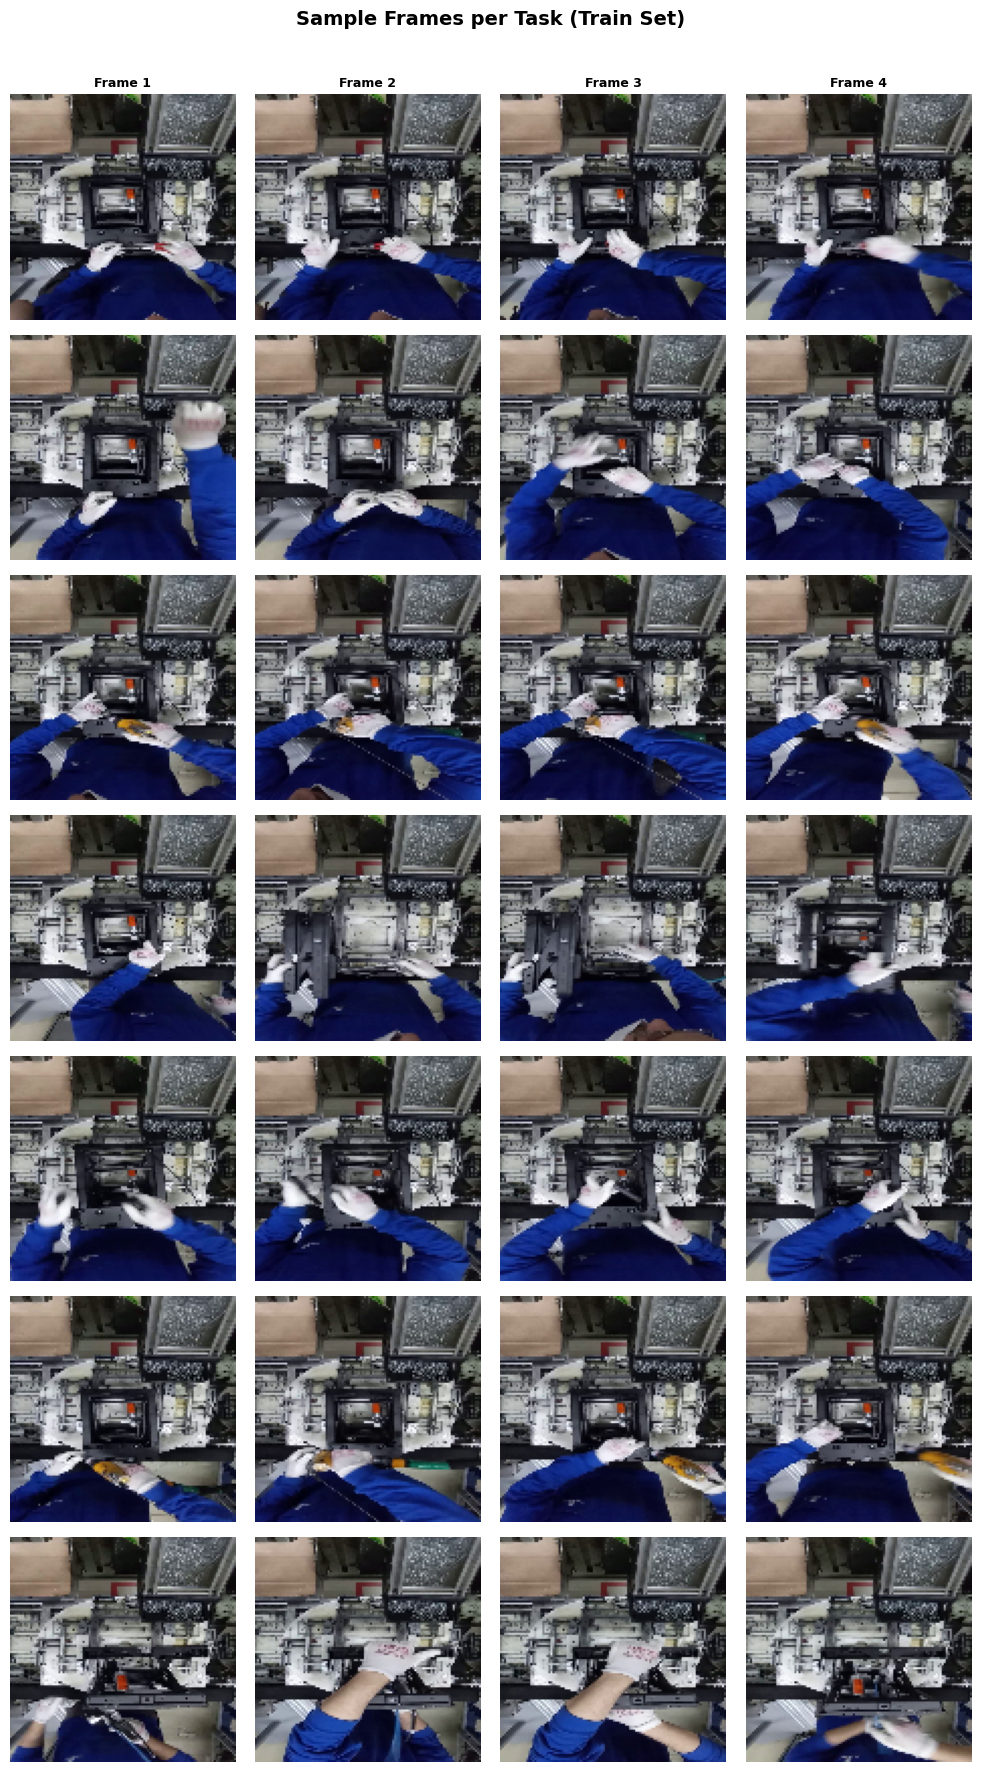

In [ ]:
fig, axes = plt.subplots(N_CLASSES, N_FRAMES, figsize=(N_FRAMES * 2.5, N_CLASSES * 2.5))
fig.patch.set_facecolor('white')

for task_idx in range(N_CLASSES):
    task_key = f'task_{task_idx}'
    row_df   = df[(df['task'] == task_key) & (df['split'] == 'train')]
    if row_df.empty:
        continue

    cycle_name = row_df.iloc[0]['cycle']
    video_path = row_df.iloc[0]['path']
    frames     = sample_frames(video_path, N_FRAMES, IMG_SIZE)

    for f_idx in range(N_FRAMES):
        ax = axes[task_idx, f_idx]
        if frames is not None:
            ax.imshow(frames[f_idx])
        ax.axis('off')

        if task_idx == 0:
            ax.set_title(f'Frame {f_idx+1}', color='black', fontsize=9, fontweight='bold')

    axes[task_idx, 0].set_ylabel(
        f'[Task {task_idx}] {SHORT_NAMES[task_idx]}\n{cycle_name}',
        color='black', fontsize=8.5, fontweight='bold',
        rotation=0, labelpad=120, va='center'
    )

plt.suptitle('Sample Frames per Task (Train Set)',
             color='black', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(OUTPUT_PATH / 'sample_frames.png'), dpi=100,
            bbox_inches='tight', facecolor='white')
plt.show()

## **5. Build tf.data Pipeline**

In [ ]:
def make_dataset(df_split, n_frames=8, img_size=(112,112),
                 batch_size=8, shuffle=False, augment=False):
    """
    Buat tf.data.Dataset dari DataFrame split.
    Tidak load semua ke RAM — baca per batch.
    """
    paths  = df_split['path'].values
    labels = df_split['label_id'].values.astype(np.int32)

    def load_video(path, label):
        """Load satu video → tensor frames."""
        def _load(p):
            p_str = p.numpy().decode('utf-8')
            frames = sample_frames(p_str, n_frames, img_size)
            if frames is None:
                frames = np.zeros((n_frames, *img_size, 3), dtype=np.float32)
            return frames.astype(np.float32)

        frames_tensor = tf.py_function(_load, [path], tf.float32)
        frames_tensor.set_shape([n_frames, *img_size, 3])
        label_oh = tf.one_hot(label, N_CLASSES)
        return frames_tensor, label_oh

    def augment_fn(frames, label):
        """Augmentasi ringan — horizontal flip & brightness."""
        if tf.random.uniform(()) > 0.5:
            frames = tf.image.flip_left_right(frames)
        frames = tf.image.random_brightness(frames, max_delta=0.1)
        frames = tf.clip_by_value(frames, 0.0, 1.0)
        return frames, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42)
    ds = ds.map(load_video, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


df_train = df[df['split'] == 'train']
df_val   = df[df['split'] == 'val']
df_test  = df[df['split'] == 'test']

train_ds = make_dataset(df_train, N_FRAMES, IMG_SIZE, BATCH_SIZE, shuffle=True,  augment=True)
val_ds   = make_dataset(df_val,   N_FRAMES, IMG_SIZE, BATCH_SIZE, shuffle=False, augment=False)
test_ds  = make_dataset(df_test,  N_FRAMES, IMG_SIZE, BATCH_SIZE, shuffle=False, augment=False)

print(f'   Train : {len(df_train)} videos → {len(train_ds)} batches')
print(f'   Val   : {len(df_val)} videos → {len(val_ds)} batches')
print(f'   Test  : {len(df_test)} videos → {len(test_ds)} batches')

cw_arr  = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=df_train['label_id'].values)
cw_dict = dict(enumerate(cw_arr))

   Train : 378 videos → 48 batches
   Val   : 84 videos → 11 batches
   Test  : 84 videos → 11 batches


## **6. Build Model: MobileNetV2 + LSTM**

In [ ]:
def build_model(n_frames, img_size, n_classes, lstm_units=64, dropout=0.4):
    """
    MobileNetV2 (frozen) sebagai feature extractor per frame,
    dilanjutkan LSTM untuk temporal reasoning.
    """
    base_model = MobileNetV2(
        input_shape=(*img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # Input: sequence of frames
    inputs = keras.Input(shape=(n_frames, *img_size, 3), name='video_input')

    # Ekstrak fitur per frame
    x = layers.TimeDistributed(base_model, name='mobilenet_td')(inputs)
    x = layers.TimeDistributed(layers.GlobalAveragePooling2D(), name='gap_td')(x)
    # x shape: (batch, n_frames, 1280)

    # Temporal reasoning
    x = layers.LSTM(lstm_units, dropout=dropout, name='lstm')(x)
    x = layers.BatchNormalization(name='bn')(x)

    # Classifier
    x = layers.Dense(64, activation='relu', name='dense')(x)
    x = layers.Dropout(dropout, name='dropout')(x)
    outputs = layers.Dense(n_classes, activation='softmax', name='output')(x)

    model = keras.Model(inputs, outputs, name='HATRec_MobileNetV2_LSTM')
    return model, base_model


model, base_model = build_model(N_FRAMES, IMG_SIZE, N_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

model.summary()
total_params = model.count_params()
trainable    = sum([np.prod(v.shape) for v in model.trainable_variables])
print(f'\n  Total params     : {total_params:,}')
print(f'  Trainable params : {trainable:,} (MobileNetV2 frozen)')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "HATRec_MobileNetV2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ video_input (InputLayer)        │ (None, 4, 112, 112, 3) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenet_td (TimeDistributed)  │ (None, 4, 4, 4, 1280)  │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap_td (TimeDistributed)        │ (None, 4, 1280)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn (BatchNormalization)         │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,175 (9.95 MB)

 Trainable params: 349,063 (1.33 MB)

 Non-trainable params: 2,258,112 (8.61 MB)


  Total params     : 2,607,175
  Trainable params : 349,063 (MobileNetV2 frozen)


## **7. Training The Model**

In [ ]:
#Phase 1
print(f'Epochs : 15 | LR : 1e-3 | Batch : {BATCH_SIZE}\n')

cb_phase1 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(OUTPUT_PATH / 'best_phase1.h5'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

hist1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=cw_dict,
    callbacks=cb_phase1,
    verbose=1
)

best1 = max(hist1.history['val_accuracy'])
print(f'\nPhase 1 - Best val acc: {best1:.1%}')

Epochs : 15 | LR : 1e-3 | Batch : 8

Epoch 1/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2306 - loss: 2.1312 - precision: 0.2486 - recall: 0.0658
Epoch 1: val_accuracy improved from None to 0.51190, saving model to /content/hatrec_output/best_phase1.h5



Epoch 1: finished saving model to /content/hatrec_output/best_phase1.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 318s 6s/step - accuracy: 0.2698 - loss: 2.0192 - precision: 0.3265 - recall: 0.0847 - val_accuracy: 0.5119 - val_loss: 1.7059 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4343 - loss: 1.4890 - precision: 0.5871 - recall: 0.1690
Epoch 2: val_accuracy improved from 0.51190 to 0.86905, saving model to /content/hatrec_output/best_phase1.h5



Epoch 2: finished saving model to /content/hatrec_output/best_phase1.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.4868 - loss: 1.3851 - precision: 0.7040 - recall: 0.2328 - val_accuracy: 0.8690 - val_loss: 1.3978 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6716 - loss: 0.9555 - precision: 0.8627 - recall: 0.4099
Epoch 3: val_accuracy improved from 0.86905 to 0.91667, saving model to /content/hatrec_output/best_phase1.h5



Epoch 3: finished saving model to /content/hatrec_output/best_phase1.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.6958 - loss: 0.9154 - precision: 0.8698 - recall: 0.4418 - val_accuracy: 0.9167 - val_loss: 0.9242 - val_precision: 1.0000 - val_recall: 0.2619
Epoch 4/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7788 - loss: 0.7136 - precision: 0.8614 - recall: 0.5807
Epoch 4: val_accuracy did not improve from 0.91667
48/48 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8042 - loss: 0.6593 - precision: 0.8977 - recall: 0.6270 - val_accuracy: 0.9048 - val_loss: 0.5502 - val_precision: 0.9818 - val_recall: 0.6429
Epoch 5/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8205 - loss: 0.5268 - precision: 0.8874 - recall: 0.7350
Epoch 5: val_accuracy improved from 0.91667 to 0.94048, saving model to /content/hatrec_output/best_phase1.h5



Epoch 5: finished saving model to /content/hatrec_output/best_phase1.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.8175 - loss: 0.5260 - precision: 0.8924 - recall: 0.7460 - val_accuracy: 0.9405 - val_loss: 0.3964 - val_precision: 0.9714 - val_recall: 0.8095
Epoch 6/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8452 - loss: 0.4926 - precision: 0.9117 - recall: 0.7629
Epoch 6: val_accuracy improved from 0.94048 to 0.95238, saving model to /content/hatrec_output/best_phase1.h5



Epoch 6: finished saving model to /content/hatrec_output/best_phase1.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.8704 - loss: 0.4519 - precision: 0.9193 - recall: 0.7831 - val_accuracy: 0.9524 - val_loss: 0.2156 - val_precision: 0.9870 - val_recall: 0.9048
Epoch 7/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8862 - loss: 0.3338 - precision: 0.9265 - recall: 0.8473
Epoch 7: val_accuracy improved from 0.95238 to 0.98810, saving model to /content/hatrec_output/best_phase1.h5



Epoch 7: finished saving model to /content/hatrec_output/best_phase1.h5
48/48 ━━━━━━━━━━━━━━━━━━━━ 115s 2s/step - accuracy: 0.8677 - loss: 0.3490 - precision: 0.9107 - recall: 0.8360 - val_accuracy: 0.9881 - val_loss: 0.0934 - val_precision: 0.9878 - val_recall: 0.9643
Epoch 8/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8739 - loss: 0.3333 - precision: 0.9191 - recall: 0.8435
Epoch 8: val_accuracy did not improve from 0.98810
48/48 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.8915 - loss: 0.3238 - precision: 0.9251 - recall: 0.8492 - val_accuracy: 0.9881 - val_loss: 0.0770 - val_precision: 1.0000 - val_recall: 0.9762
Epoch 9/15
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9338 - loss: 0.2604 - precision: 0.9536 - recall: 0.9026
Epoch 9: val_accuracy did not improve from 0.98810
48/48 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.9286 - loss: 0.2853 - precision: 0.9516 - recall: 0.8836 - val_accuracy: 0.9762 - val_loss: 0.0604 - val_precision: 0.9762 - val_recall

In [ ]:
#Phase 2

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_p2 = sum([np.prod(v.shape) for v in model.trainable_variables])
print(f'   Trainable params phase 2: {trainable_p2:,}')

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

cb_phase2 = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7,
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=1e-6, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        str(OUTPUT_PATH / 'best_model.h5'),
        monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print(f'\n🚀 Phase 2: Fine-tuning...')
print(f'   Epochs : {EPOCHS} | LR : 1e-4 | Batch : {BATCH_SIZE}\n')

hist2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=cw_dict,
    callbacks=cb_phase2,
    verbose=1
)

best2 = max(hist2.history['val_accuracy'])
print(f'\nPhase 2 - Best val acc: {best2:.1%}')

## **8. Model Evaluation**

In [ ]:
# Training curves
acc   = hist1.history['accuracy']      + hist2.history['accuracy']
val_a = hist1.history['val_accuracy']  + hist2.history['val_accuracy']
loss  = hist1.history['loss']          + hist2.history['loss']
val_l = hist1.history['val_loss']      + hist2.history['val_loss']
ep    = range(1, len(acc) + 1)
p1_end = len(hist1.history['accuracy'])

plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')

for ax, train_m, val_m, title in zip(
    axes,
    [loss, acc], [val_l, val_a],
    ['Training Loss', 'Training Accuracy']
):
    ax.plot(ep, train_m, color='#00a884', linewidth=2, label='Train')
    ax.plot(ep, val_m,   color='#d84315', linewidth=2, linestyle='--', label='Val')

    ax.axvline(p1_end, color='gray', linestyle=':', alpha=0.8, label='Phase 2 start')

    ax.set_title(title, color='black', fontweight='bold')
    ax.set_xlabel('Epoch', color='black')
    ax.set_facecolor('#fdfdfd')
    ax.tick_params(colors='black')

    ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7)

    ax.legend(facecolor='white', edgecolor='black', labelcolor='black')

axes[1].set_ylim(0, 1)

plt.suptitle('Training History',
             color='black', fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

In [ ]:
y_pred_prob, y_true = [], []

for frames_batch, labels_batch in test_ds:
    preds = model.predict(frames_batch, verbose=0)
    y_pred_prob.extend(preds)
    y_true.extend(np.argmax(labels_batch.numpy(), axis=1))

y_pred_prob = np.array(y_pred_prob)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.array(y_true)

test_acc = accuracy_score(y_true, y_pred)
test_f1  = f1_score(y_true, y_pred, average='weighted')
f1_per   = f1_score(y_true, y_pred, average=None)

print('\n' + '='*55)
print('  TEST SET RESULTS')
print('='*55)
print(f'  Accuracy     : {test_acc:.4f} ({test_acc:.1%})')
print(f'  F1 (weighted): {test_f1:.4f}')
print('='*55)
print('\nClassification Report:')

present = sorted(np.unique(np.concatenate([y_true, y_pred])))
present_names = [SHORT_NAMES[i] for i in present]
print(classification_report(y_true, y_pred, labels=present,
                             target_names=present_names, digits=3))

In [ ]:
cm      = confusion_matrix(y_true, y_pred, labels=present)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.style.use('default')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')
for ax, data, fmt, title, cmap in zip(
    axes,
    [cm, cm_norm], ['d', '.2f'],
    ['Confusion Matrix (Count)', 'Confusion Matrix (Normalized)'],
    ['Blues', 'RdYlGn']

    sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                xticklabels=present_names, yticklabels=present_names,
                ax=ax, linewidths=0.5, linecolor='lightgray')

    ax.set_title(title, color='black', fontweight='bold')
    ax.set_xlabel('Predicted', color='black')
    ax.set_ylabel('Actual', color='black')
    ax.tick_params(colors='black', labelsize=8)

    ax.set_facecolor('white')

plt.suptitle('Confusion Matrix',
             color='black', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
plt.style.use('default')

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

colors = ['#00c853' if f >= 0.8 else '#ffd600' if f >= 0.6 else '#f44336'
          for f in f1_per]
bars = ax.bar(present_names, f1_per, color=colors, alpha=0.85)

for bar, val in zip(bars, f1_per):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1f}', ha='center', va='bottom',
            color='black', fontsize=10)

ax.axhline(0.8, color='#009688', linestyle='--', label='Target 80%')
ax.axhline(test_f1, color='#d84315', linestyle=':',
           label=f'Overall F1: {test_f1:.3f}')

ax.set_ylim(0, 1.1)

ax.set_title('F1 Score per Task', color='black', fontweight='bold', fontsize=13)
ax.set_xlabel('Task', color='black')
ax.set_ylabel('F1 Score', color='black')
ax.tick_params(colors='black')

ax.grid(color='lightgray', linestyle='-', linewidth=0.5, alpha=0.7, axis='y', zorder=0)

ax.legend(fontsize=10, facecolor='white', edgecolor='black', labelcolor='black')

plt.tight_layout()
plt.show()

## **9. Frame per task extraction**

In [ ]:
plt.style.use('default')

fig, axes = plt.subplots(2, 4, figsize=(22, 11))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for task_idx in range(N_CLASSES):
    ax       = axes[task_idx]
    task_key = f'task_{task_idx}'
    task_df  = df[(df['task'] == task_key) & (df['split'] == 'test')]

    if task_df.empty:
        ax.axis('off')
        continue

    video_path = task_df.iloc[0]['path']
    frames     = sample_frames(video_path, N_FRAMES, IMG_SIZE)

    if frames is None:
        ax.axis('off')
        continue

    pred_prob  = model.predict(frames[np.newaxis], verbose=0)[0]
    pred_id    = np.argmax(pred_prob)
    confidence = pred_prob[pred_id]
    is_correct = (pred_id == task_idx)

    mid_frame  = frames[N_FRAMES // 2]
    ax.imshow(mid_frame)

    status       = 'CORRECT' if is_correct else 'WRONG'
    title_color  = '#00c853' if is_correct else '#f44336'
    pred_name    = SHORT_NAMES[pred_id]

    ax.set_title(
        f'[Task {task_idx}] {SHORT_NAMES[task_idx]}\n'
        f'Pred: {pred_name} ({confidence:.1%})\n'
        f'{status}',
        color=title_color, fontsize=9, fontweight='bold'
    )
    ax.axis('off')

    ax_bar = ax.inset_axes([0, -0.12, 1, 0.08])

    bar_colors = ['#00c853' if i == task_idx else
                  '#f44336' if i == pred_id else '#777'
                  for i in range(N_CLASSES)]
    ax_bar.bar(range(N_CLASSES), pred_prob, color=bar_colors, alpha=0.8)


    ax_bar.set_xticks(range(N_CLASSES))
    ax_bar.set_xticklabels([str(i) for i in range(N_CLASSES)],
                           color='black', fontsize=6)
    ax_bar.set_ylim(0, 1)

    ax_bar.tick_params(colors='black', labelsize=6)


    ax_bar.set_facecolor('#fdfdfd')


    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)

    ax_bar.spines['bottom'].set_color('black')
    ax_bar.spines['left'].set_color('black')

axes[7].axis('off')

plt.suptitle('🔍 Per-Task Evaluation: Frame + Confidence Bar',
             color='black', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.subplots_adjust(hspace=0.5)
plt.show()

## **10. Export model and json for deployment**

In [ ]:
import shutil


print(f'Semua file disalin ke Google Drive: HATRec_Model/')
print('\nOutput files:')
for f in sorted(drive_out.iterdir()):
    print(f'   {f.name:45s}: {f.stat().st_size/1024/1024:.2f} MB')

model.save(str(OUTPUT_PATH / 'hatrec_mobilenetv2.h5'))

print('   Converting to TFLite (quantized)...')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False


tflite_model = converter.convert()
with open(str(OUTPUT_PATH / 'hatrec_mobilenetv2.tflite'), 'wb') as f:
    f.write(tflite_model)


config = {
    'n_classes'  : N_CLASSES,
    'class_names': CLASS_NAMES,
    'short_names': SHORT_NAMES,
    'label_map'  : LABEL_MAP,
    'n_frames'   : N_FRAMES,
    'img_size'   : list(IMG_SIZE)
}
with open(str(OUTPUT_PATH / 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)

metrics = {
    'test_accuracy'    : round(float(test_acc), 4),
    'test_f1_weighted' : round(float(test_f1), 4),
    'best_val_acc_p1'  : round(float(best1), 4),
    'best_val_acc_p2'  : round(float(best2), 4),
    'f1_per_class'     : {SHORT_NAMES[i]: round(float(f1_per[i]), 4)
                          for i in range(len(f1_per))}
}
with open(str(OUTPUT_PATH / 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print('   ✅ metrics.json')

# Upload to gdrive
drive_out = Path('/content/drive/MyDrive/Colab Notebooks/00. Final Project/HATRec_Model')
drive_out.mkdir(parents=True, exist_ok=True)
for f in OUTPUT_PATH.iterdir():
    shutil.copy(str(f), str(drive_out / f.name))

